In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import fetch_daily_data
import os

# Load data

In [14]:
df_base = fetch_daily_data('SPY')
df_base

An error occurred while fetching data for SPY: Too Many Requests. Rate limited. Try after a while.


""


In [12]:
df_base['returns'] = df_base['adjclose'].pct_change() + 1
df_base['returns'] = df_base['returns'].fillna(1.0)
df_base['vol'] = df_base['returns'].rolling(window=21).std() * np.sqrt(252)
df_base['forward_vol'] = df_base['vol'].shift(-21)
df_base['forward_returns'] = df_base['returns'].rolling(21).apply(np.prod).shift(-21)
df_base

df_leveraged = df_base.copy()
leverage = 3.0
expense_ratio = 0.0045  # 0.45% annual expense ratio
df_leveraged['returns'] = (df_leveraged['returns'] - 1) * leverage + 1 - (expense_ratio / 252)
df_leveraged['adjclose'] = df_leveraged['returns'].cumprod() * df_base['adjclose'].to_list()[0]
df_leveraged['forward_returns'] = df_leveraged['returns'].rolling(21).apply(np.prod).shift(-21)
df_leveraged

plt.figure(figsize=(12, 6))
plt.plot(df_base['adjclose'], label='SPY')
plt.plot(df_leveraged['adjclose'], label=f'SPY {leverage}x')
plt.yscale('log')
plt.legend()
plt.title('SPY vs Leveraged SPY (3x)')
plt.show()

KeyError: 'adjclose'

In [ ]:
def compute_atr(data, period=14):
    """
    Compute the Average True Range (ATR).

    Parameters:
        data (pd.DataFrame): Must contain columns ['High', 'Low', 'Close'].
        period (int): Number of periods to calculate ATR (default=14).

    Returns:
        pd.Series: ATR values.
    """
    # True Range (TR)
    high_low = data['high'] - data['low']
    high_close = (data['high'] - data['close'].shift()).abs()
    low_close = (data['low'] - data['close'].shift()).abs()
    
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)

    # Average True Range (ATR)
    atr = tr.rolling(window=period, min_periods=1).mean()

    return atr

df_base['atr'] = compute_atr(df_base, period=21)

Correlation between VIX and Forward Volatility: 0.7173954124026874
R2 between VIX and Forward Volatility: 0.514656177736422


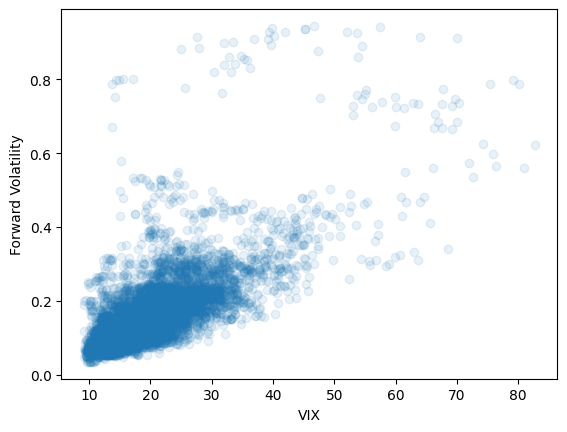

Coefficients: [0.00811001 0.07144048 0.00073309]
Intercept: -0.012613387096501588
R2 of combined model: 0.5166775250090438


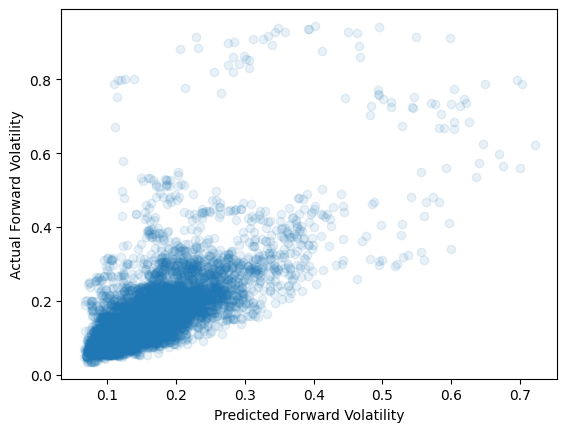

In [ ]:
df_vix = fetch_daily_data('^VIX')
df_vix

df_base['vix'] = df_vix['adjclose']

print("Correlation between VIX and Forward Volatility:", df_base[['vix', 'forward_vol']].corr().iloc[0,1])
print("R2 between VIX and Forward Volatility:", df_base[['vix', 'forward_vol']].dropna().corr().iloc[0,1]**2)
plt.plot(df_base['vix'], df_base['forward_vol'], 'o', alpha=0.1)
plt.xlabel('VIX')
plt.ylabel('Forward Volatility')
plt.show()

# print("Correlation between Volatility and Forward Volatility:", df_base[['vol', 'forward_vol']].corr().iloc[0,1])
# print("R2 between Volatility and Forward Volatility:", df_base[['vol', 'forward_vol']].dropna().corr().iloc[0,1]**2)
# plt.plot(df_base['forward_vol'], df_base['vol'], 'o', alpha=0.1)
# plt.show()

# print("Correlation between ATR and Forward Volatility:", df_base[['atr', 'forward_vol']].corr().iloc[0,1])
# print("R2 between ATR and Forward Volatility:", df_base[['atr', 'forward_vol']].dropna().corr().iloc[0,1]**2)
# plt.plot(df_base['forward_vol'], df_base['atr'], 'o', alpha=0.1)
# plt.show()

from sklearn.linear_model import LinearRegression
model = LinearRegression()
df_test = df_base[['vix', 'vol', 'atr', 'forward_vol']].dropna()
X = df_test[['vix', 'vol', 'atr']]
y = df_test['forward_vol']
model.fit(X, y)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

print("R2 of combined model:", model.score(X, y))
plt.plot(model.predict(X), y, 'o', alpha=0.1)
plt.xlabel('Predicted Forward Volatility')
plt.ylabel('Actual Forward Volatility')
plt.show()

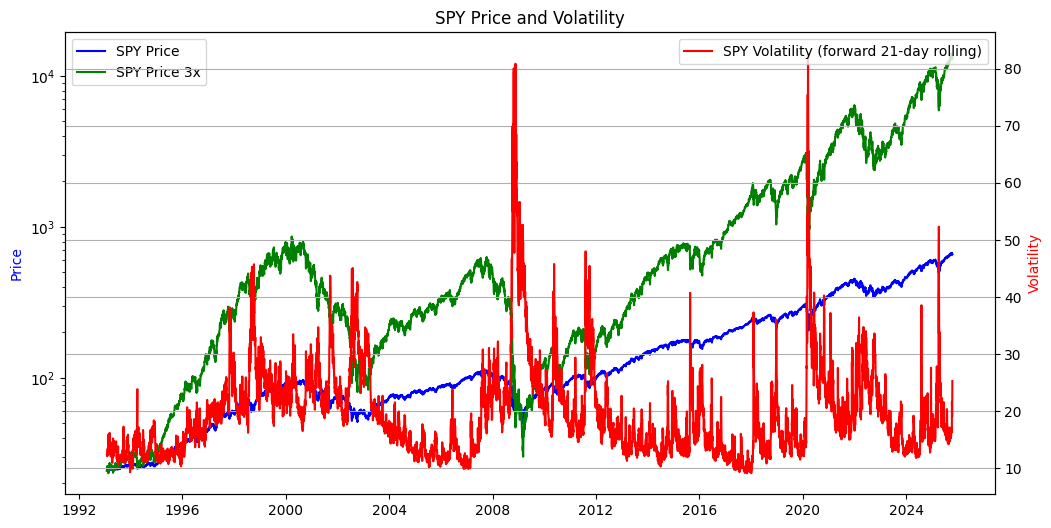

In [ ]:


fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(df_base['adjclose'], color='blue', label='SPY Price')
ax1.plot(df_leveraged['adjclose'], color='green', label='SPY Price 3x')
ax2.plot(df_base['vix'], color='red', label='SPY Volatility (forward 21-day rolling)')
ax1.set_yscale('log')
ax1.set_ylabel('Price', color='blue')
ax2.set_ylabel('Volatility', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.grid()
plt.title('SPY Price and Volatility')
plt.show()

Base best fit coefficients: [-0.16292096  1.0354618 ]
base r2: 0.1292174964905445
Leveraged best fit coefficients: [-0.53170811  1.11102307]
leveraged r2: 0.15268584658156148


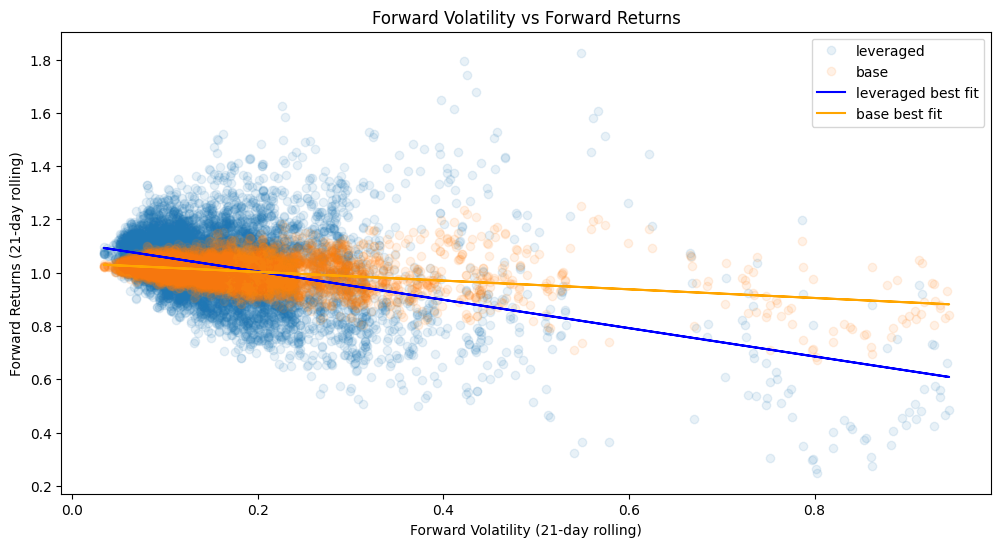

In [ ]:
base_best_fit = np.polyfit(df_base['forward_vol'].dropna(), df_base['forward_returns'].dropna(), 1)
leveraged_best_fit = np.polyfit(df_base['forward_vol'].dropna(), df_leveraged['forward_returns'].dropna(), 1)
print("Base best fit coefficients:", base_best_fit)
print("base r2:", np.corrcoef(df_base['forward_vol'].dropna(), df_base['forward_returns'].dropna())[0,1]**2)

print("Leveraged best fit coefficients:", leveraged_best_fit)
print("leveraged r2:", np.corrcoef(df_base['forward_vol'].dropna(), df_leveraged['forward_returns'].dropna())[0,1]**2)


plt.figure(figsize=(12, 6))

plt.plot(df_base['forward_vol'], df_leveraged['forward_returns'], marker='o', linestyle='', alpha=0.1, label='leveraged')
plt.plot(df_base['forward_vol'], df_base['forward_returns'], marker='o', linestyle='', alpha=0.1, label='base')

plt.plot(df_base['forward_vol'], np.polyval(leveraged_best_fit, df_base['forward_vol']), color='blue', label='leveraged best fit')
plt.plot(df_base['forward_vol'], np.polyval(base_best_fit, df_base['forward_vol']), color='orange', label='base best fit')



plt.xlabel('Forward Volatility (21-day rolling)')
plt.ylabel('Forward Returns (21-day rolling)')
plt.title('Forward Volatility vs Forward Returns')
plt.legend()
plt.show()

Base best fit coefficients: [-5.46667678e-05  1.00951389e+00]
base r2: 0.0006437396928156558
Leveraged best fit coefficients: [-1.01062396e-04  1.02633867e+00]
leveraged r2: 0.00024407960795361762


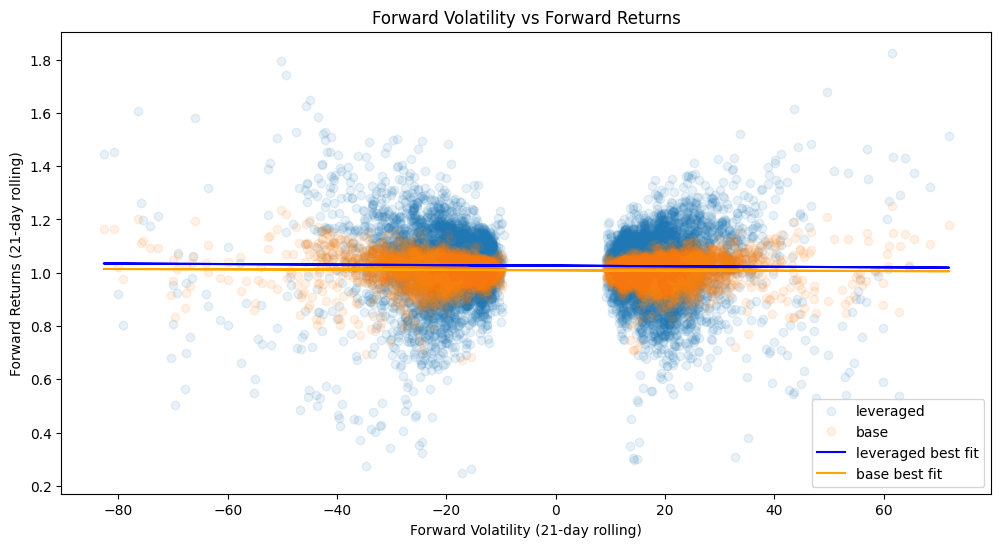

In [ ]:
df_plot = df_base.copy()
df_plot['vix'] = np.where(df_plot['vix'].shift(5) > df_plot['vix'], df_plot['vix'], -df_plot['vix'])
df_plot.dropna(inplace=True)
df_plot['forward_returns_leveraged'] = df_leveraged['forward_returns'].loc[df_plot.index]

base_best_fit = np.polyfit(df_plot['vix'].dropna(), df_plot['forward_returns'].dropna(), 1)
leveraged_best_fit = np.polyfit(df_plot['vix'].dropna(), df_plot['forward_returns_leveraged'].dropna(), 1)

print("Base best fit coefficients:", base_best_fit)
print("base r2:", np.corrcoef(df_plot['vix'].dropna(), df_plot['forward_returns'].dropna())[0,1]**2)

print("Leveraged best fit coefficients:", leveraged_best_fit)
print("leveraged r2:", np.corrcoef(df_plot['vix'].dropna(), df_plot['forward_returns_leveraged'].dropna())[0,1]**2)


plt.figure(figsize=(12, 6))

plt.plot(df_plot['vix'], df_plot['forward_returns_leveraged'], marker='o', linestyle='', alpha=0.1, label='leveraged')
plt.plot(df_plot['vix'], df_plot['forward_returns'], marker='o', linestyle='', alpha=0.1, label='base')

plt.plot(df_plot['vix'], np.polyval(leveraged_best_fit, df_plot['vix']), color='blue', label='leveraged best fit')
plt.plot(df_plot['vix'], np.polyval(base_best_fit, df_plot['vix']), color='orange', label='base best fit')



plt.xlabel('Forward Volatility (21-day rolling)')
plt.ylabel('Forward Returns (21-day rolling)')
plt.title('Forward Volatility vs Forward Returns')
plt.legend()
plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

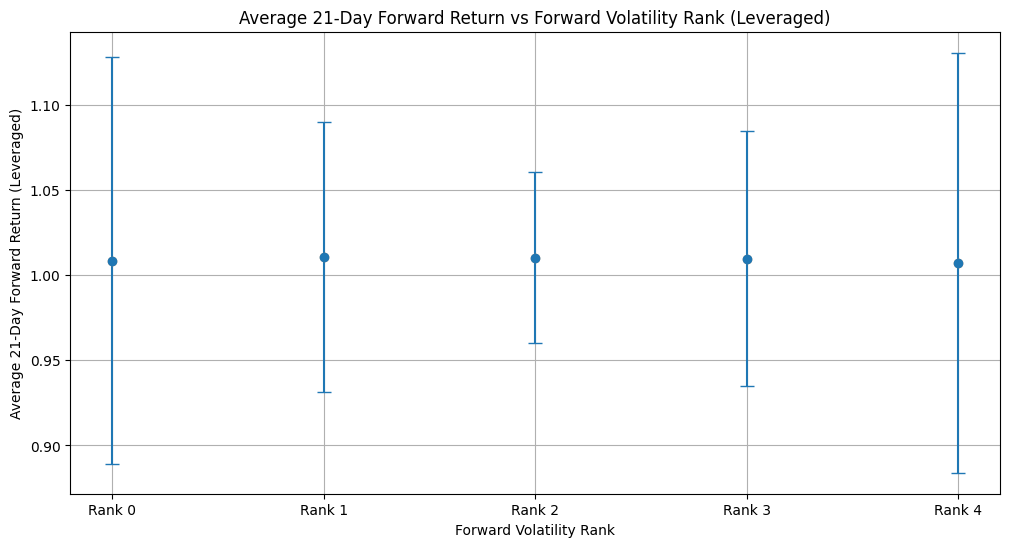

In [ ]:


num_ranks = 5
df = pd.DataFrame()
df['base_returns'] = df_base['returns']
df['leveraged_returns'] = df_leveraged['returns']
df['forward_21d_base'] = df_base['forward_returns']
df['forward_21d_leveraged'] = df_leveraged['forward_returns'] / df['forward_21d_base']
df['past_returns_252d'] = df_base['returns'].rolling(252).apply(np.prod).shift(1)
df['past_returns_252d_lagged'] = df['past_returns_252d'].shift(21)
df['momentum'] = np.where(df['past_returns_252d_lagged'] > 1.0, 1, 0.01)
df['diff_21d'] = df['forward_21d_leveraged'] / df['forward_21d_base']
# df['forward_vol'] = df_base['forward_vol']
df['forward_vol'] = np.where(df_base['vix'].shift(1) < df_base['vix'], df_base['vix'], -df_base['vix'])
# df['forward_vol'] = (df_base['vix']) * df['momentum']
# df['forward_vol'] = df_base['vol']
df['forward_vol_rank'] = pd.qcut(df['forward_vol'], q=num_ranks, labels=range(num_ranks))

df

avg_forward_21d_base = []
std_forward_21d_base = []
for rank in tqdm(range(num_ranks)):
    mask = df['forward_vol_rank'] == rank
    # avg_forward_21d_base.append(df.loc[mask, 'forward_21d_leveraged'].mean())
    avg_forward_21d_base.append(df.loc[mask, 'diff_21d'].median())
    std_forward_21d_base.append(df.loc[mask, 'forward_21d_leveraged'].std())

plt.figure(figsize=(12, 6))
plt.errorbar(range(num_ranks), avg_forward_21d_base, yerr=std_forward_21d_base, fmt='o', capsize=5)
plt.xticks(range(num_ranks), [f'Rank {i}' for i in range(num_ranks)])
plt.xlabel('Forward Volatility Rank')
plt.ylabel('Average 21-Day Forward Return (Leveraged)')
plt.title('Average 21-Day Forward Return vs Forward Volatility Rank (Leveraged)')
plt.grid()

plt.plot(range(num_ranks), avg_forward_21d_base, 'o', alpha=0.5)
plt.show()

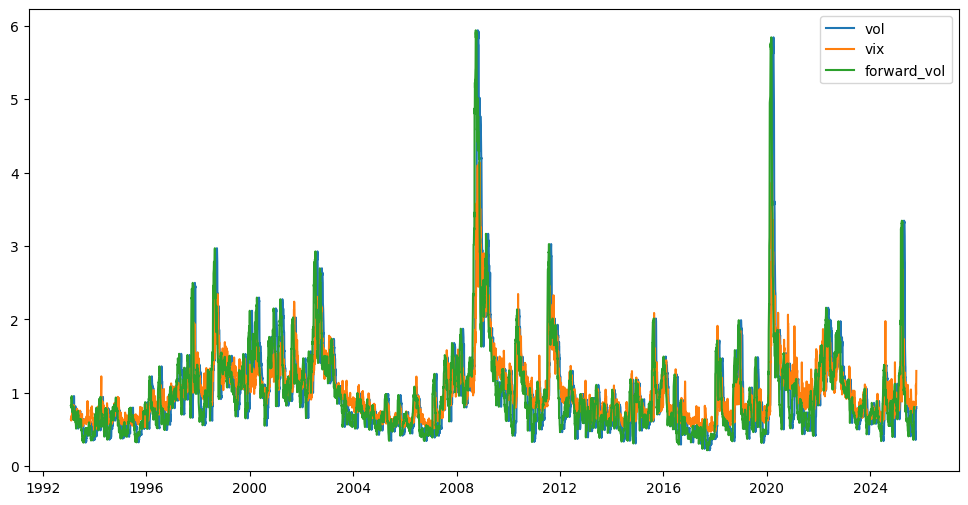

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_base['vol'] / df_base['vol'].mean(), label='vol')
plt.plot(df_base['vix'] / df_base['vix'].mean(), label='vix')
plt.plot(df_base['forward_vol'] / df_base['forward_vol'].mean(), label='forward_vol')
plt.legend()
plt.show()

In [ ]:
for i, r in df.iterrows():
    if r['forward_vol_rank'] == 4:
        print(i, r['forward_vol'], r['forward_21d_base'], r['forward_21d_leveraged'], r['diff_21d'])

1994-04-04 00:00:00 23.8700008392334 1.0306044698016368 1.0590610241564251 1.0276115184715484
1996-07-23 00:00:00 21.549999237060547 1.0623133349699323 1.1238942801920995 1.0579687208990087
1996-07-24 00:00:00 21.440000534057617 1.0701493851146278 1.1402555812967676 1.0655106634244624
1996-12-13 00:00:00 21.09000015258789 1.0524615856816575 1.1007427721358156 1.04587453557546
1996-12-16 00:00:00 21.989999771118164 1.070433798740179 1.139179500470433 1.064222282415935
1997-01-02 00:00:00 21.139999389648438 1.0590961956827747 1.1161438896560634 1.0538645065536387
1997-02-20 00:00:00 21.40999984741211 0.9800125059547045 0.9557750618975176 0.9752682298338884
1997-02-28 00:00:00 21.100000381469727 0.9620200843282621 0.9179817173820457 0.9542230274984679
1997-03-18 00:00:00 21.260000228881836 0.9675172198989876 0.9249382095419924 0.9559914702485185
1997-03-19 00:00:00 21.739999771118164 0.9755580090704262 0.9403406485913127 0.963900290754959
1997-03-20 00:00:00 21.219999313354492 0.974211608